<a href="https://colab.research.google.com/github/LojainAhmad25/cybersecurity-intrusion-detection/blob/main/Cybersecurity_Intrusion_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler




In [12]:
path = kagglehub.dataset_download("dnkumars/cybersecurity-intrusion-detection-dataset")
print("Dataset folder path:", path)

Dataset folder path: /root/.cache/kagglehub/datasets/dnkumars/cybersecurity-intrusion-detection-dataset/versions/2


In [15]:
data = pd.read_csv("/root/.cache/kagglehub/datasets/dnkumars/cybersecurity-intrusion-detection-dataset/versions/2/cybersecurity_intrusion_data.csv")
print(data.shape)
data.head()

(9537, 11)


,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


In [16]:
print(data.shape)
data.head()

(9537, 11)


,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


In [17]:
data.describe()

,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected
count,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000
mean,500.430639,4.032086,792.745312,0.331338,1.517773,0.149942,0.447101
std,198.379364,1.963012,786.560144,0.177175,1.033988,0.357034,0.497220
min,64.000000,1.000000,0.500000,0.002497,0.000000,0.000000,0.000000
25%,365.000000,3.000000,231.953006,0.191946,1.000000,0.000000,0.000000
50%,499.000000,4.000000,556.277457,0.314778,1.000000,0.000000,0.000000
75%,635.000000,5.000000,1105.380602,0.453388,2.000000,0.000000,1.000000
max,1285.000000,13.000000,7190.392213,0.924299,5.000000,1.000000,1.000000


In [18]:
data.isnull().sum()
print((data.isnull().sum() / len(data) * 100).round(2))

session_id              0.00
network_packet_size     0.00
protocol_type           0.00
login_attempts          0.00
session_duration        0.00
encryption_used        20.61
ip_reputation_score     0.00
failed_logins           0.00
browser_type            0.00
unusual_time_access     0.00
attack_detected         0.00
dtype: float64


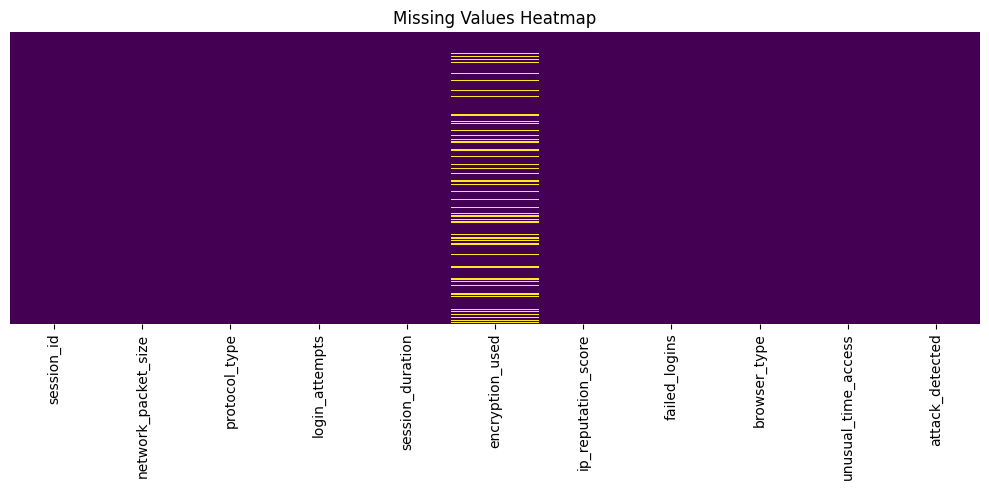

In [19]:
plt.figure(figsize=(10, 5))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title("Missing Values Heatmap")
plt.tight_layout()
plt.show()

In [20]:
# Separate column types
num_cols = data.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = data.select_dtypes(include=['object']).columns.tolist()

# Remove target from imputation
target = 'attack_detected'
if target in num_cols:
    num_cols.remove(target)

# Fill numerical columns with MEDIAN (robust to outliers)
for col in num_cols:
    if data[col].isnull().sum() > 0:
        median_val = data[col].median()
        data[col].fillna(median_val, inplace=True)
        print(f"[NUM] '{col}' filled with median: {median_val}")

# Fill categorical columns with MODE
for col in cat_cols:
    if data[col].isnull().sum() > 0:
        mode_val = data[col].mode()[0]
        data[col].fillna(mode_val, inplace=True)
        print(f"[CAT] '{col}' filled with mode: {mode_val}")

[CAT] 'encryption_used' filled with mode: AES


/tmp/ipykernel_25409/4024522765.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(mode_val, inplace=True)


In [21]:
print("\n--- After Handling ---")
print(data.isnull().sum())
print(f"\nTotal missing values: {data.isnull().sum().sum()}")


--- After Handling ---
session_id             0
network_packet_size    0
protocol_type          0
login_attempts         0
session_duration       0
encryption_used        0
ip_reputation_score    0
failed_logins          0
browser_type           0
unusual_time_access    0
attack_detected        0
dtype: int64

Total missing values: 0


In [22]:
print(f"Duplicates: {data.duplicated().sum()}")


Duplicates: 0


In [23]:
data.describe()

,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected
count,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000
mean,500.430639,4.032086,792.745312,0.331338,1.517773,0.149942,0.447101
std,198.379364,1.963012,786.560144,0.177175,1.033988,0.357034,0.497220
min,64.000000,1.000000,0.500000,0.002497,0.000000,0.000000,0.000000
25%,365.000000,3.000000,231.953006,0.191946,1.000000,0.000000,0.000000
50%,499.000000,4.000000,556.277457,0.314778,1.000000,0.000000,0.000000
75%,635.000000,5.000000,1105.380602,0.453388,2.000000,0.000000,1.000000
max,1285.000000,13.000000,7190.392213,0.924299,5.000000,1.000000,1.000000


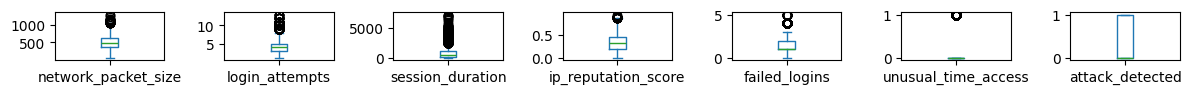

In [24]:
num_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
data[num_cols].plot(kind='box', figsize=(12, 6), subplots=True, layout=(7, 7))
plt.tight_layout()
plt.show()
# checking if data us balanced or not

In [25]:
for col in num_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = ((data[col] < lower_bound) | (data[col] > upper_bound)).sum()
    print(f"{col:25} → {outliers} outliers")


network_packet_size       → 37 outliers
login_attempts            → 206 outliers
session_duration          → 418 outliers
ip_reputation_score       → 21 outliers
failed_logins             → 323 outliers
unusual_time_access       → 1430 outliers
attack_detected           → 0 outliers


In [27]:
data=pd.DataFrame(data)


In [35]:
le = LabelEncoder()
for col in data.select_dtypes(include='object').columns:
    data[col] = le.fit_transform(data[col].astype(str))
print(data.dtypes)
x=data.iloc[:,:-1].to_numpy()

session_id               int64
network_packet_size      int64
protocol_type            int64
login_attempts           int64
session_duration       float64
encryption_used          int64
ip_reputation_score    float64
failed_logins            int64
browser_type             int64
unusual_time_access      int64
attack_detected          int64
dtype: object


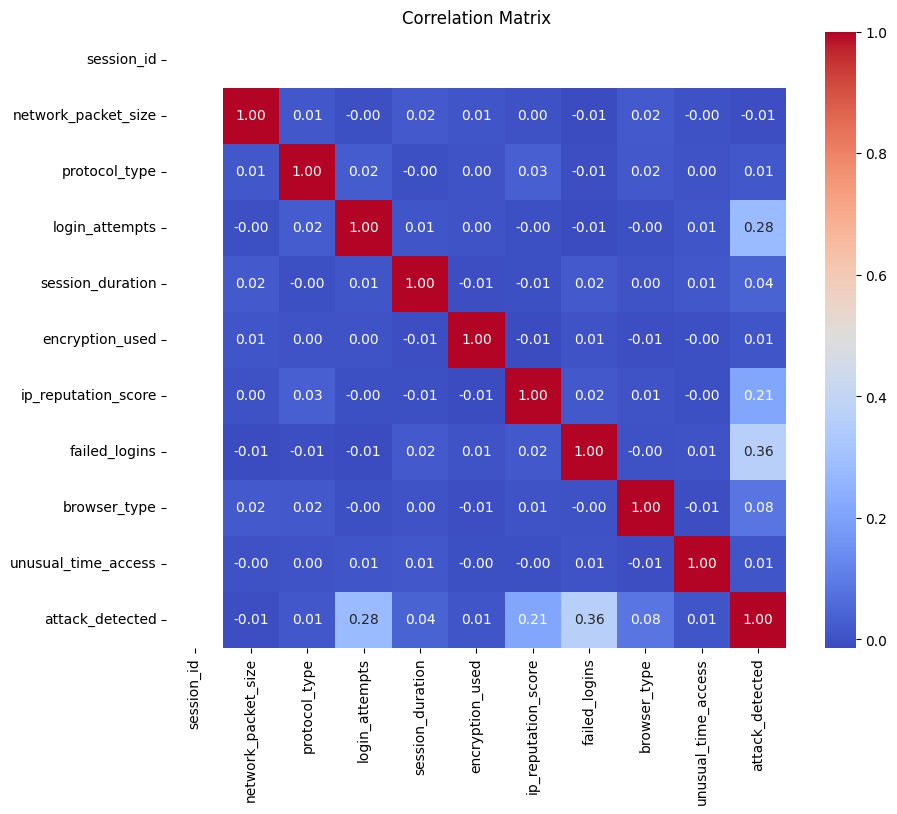

In [36]:
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [38]:
from scipy.stats import chi2_contingency

cat_cols = ['protocol_type', 'browser_type', 'encryption_used']

for col in cat_cols:
    contingency_table = pd.crosstab(data[col], data['attack_detected'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    print(f"{col:25} → chi2: {chi2:.2f} | p-value: {p:.4f} | {'keept' if p < 0.05 else 'drop'}")

protocol_type             → chi2: 2.94 | p-value: 0.2299 | drop
browser_type              → chi2: 173.80 | p-value: 0.0000 | keept
encryption_used           → chi2: 0.62 | p-value: 0.4303 | drop


In [40]:

X = data.drop(columns=['attack_detected'])
y = data['attack_detected']

# Calculate information gain
info_gain = mutual_info_classif(X, y, random_state=42)

# Put results in a dataframe
info_gain_df = pd.DataFrame({
    'Feature': X.columns,
    'Information Gain': info_gain
}).sort_values('Information Gain', ascending=False)

print(info_gain_df)

               Feature  Information Gain
7        failed_logins          0.158319
3       login_attempts          0.094859
6  ip_reputation_score          0.068250
8         browser_type          0.014293
0           session_id          0.004393
5      encryption_used          0.002198
2        protocol_type          0.001973
1  network_packet_size          0.001238
4     session_duration          0.000473
9  unusual_time_access          0.000000


/tmp/ipykernel_25409/2697577461.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Information Gain', y='Feature', data=info_gain_df, palette='coolwarm')


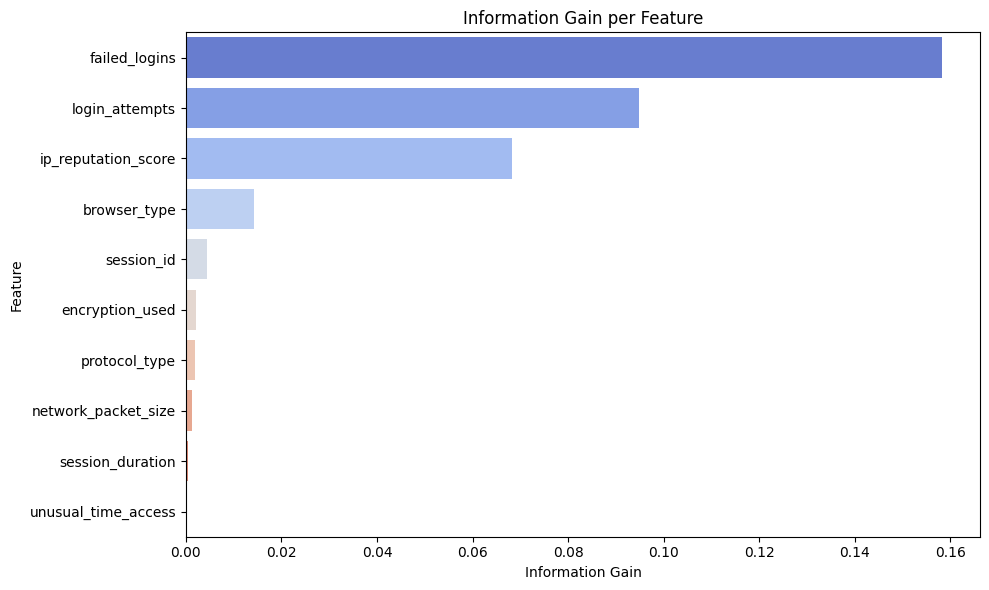

In [41]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Information Gain', y='Feature', data=info_gain_df, palette='coolwarm')
plt.title('Information Gain per Feature')
plt.tight_layout()
plt.show()

In [47]:
X = data.drop(columns=['attack_detected'])
y = data['attack_detected']

selector = SelectKBest(score_func=f_classif, k=4)
selector.fit(X, y)
X_selected = selector.transform(X)

selected_cols = X.columns[selector.get_support()]
print("Selected features:", selected_cols.tolist())

Selected features: ['login_attempts', 'ip_reputation_score', 'failed_logins', 'browser_type']


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [0] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_selected)

print("Scaling done ✓")
print(X_scaled.shape)